# Massive processing with atoms

The numpy/scipy style of the previous notebook works while the data fits in
memory. Past that you have to process in chunks, and chunking naively is
wrong: a filter that restarts at every chunk boundary leaves a transient at
each seam, so the answer depends on how you happened to cut the data.

An **atom** is a processing step that knows how to carry its state across
that seam. Every function you met in the previous notebook has one behind it.

In [1]:
import numpy as np

import xdas as xd
import xdas.atoms as xa

## From a workflow to a pipeline

Say you tried this on a small window and liked the result:

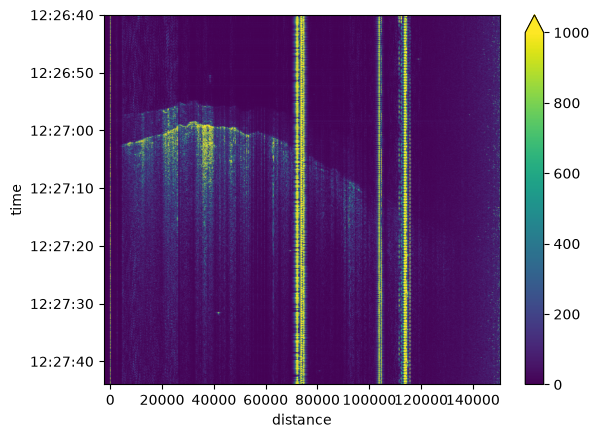

In [2]:
da = xd.open("outputs/event.nc")

def process(da):
    da = xd.resample(da, interval=250, snap=True, dim="distance")
    da = xd.filter(da, (1.0, None), ftype="iir", order=4, dim="time")
    return np.abs(da)


monolithic = process(da)
monolithic.plot(yincrease=False, vmin=0, vmax=1e3, interpolation="antialiased")

To get the pipeline behind it, call the same functions with `...` in place of
the data. Each one then returns its atom instead of applying it, and `>>`
chains them:

In [3]:
pipeline = process(...)
pipeline

Sequential:
  0: Resample(interval=250, snap=True, dim='distance')
  1: Filter(freq=(1.0, None))
  2: absolute(...)

In [4]:
pipeline = (
    xd.resample(..., interval=250, snap=True, dim="distance") 
    >> xd.filter(..., (1.0, None), ftype="iir", order=4, dim="time")
    >> np.abs
)
pipeline

Sequential:
  0: Resample(interval=250, snap=True, dim='distance')
  1: Filter(freq=(1.0, None))
  2: absolute(...)

Note the last line: under the seed, an ordinary numpy call does not compute
anything, it appends itself to the pipeline. So the pipeline reads like the
function it replaces.

The result is a callable, and on a whole array it gives exactly what the
function gave:

In [5]:
atomic = pipeline(da)
assert atomic.equals(monolithic)

## Running it chunk by chunk

`process` runs the same pipeline over a source it cuts into chunks. Here the
array is cut every 1000 samples along time:

In [6]:
chunked = pipeline.process(da, chunks={"time": 1000})
assert chunked.equals(monolithic)

  0%|          | 0.00/76.3M [00:00<?, ?B/s]

 25%|██▌       | 19.1M/76.3M [00:00<00:00, 131MB/s]

 25%|██▌       | 19.1M/76.3M [00:00<00:00, 131MB/s, read=8.5%, proc=91.4%, write=0.0%]

 50%|█████     | 38.1M/76.3M [00:00<00:00, 138MB/s, read=8.5%, proc=91.4%, write=0.0%]

 50%|█████     | 38.1M/76.3M [00:00<00:00, 138MB/s, read=0.8%, proc=99.2%, write=0.0%]

...

 75%|███████▌  | 57.2M/76.3M [00:00<00:00, 140MB/s, read=0.8%, proc=99.2%, write=0.0%]

100%|██████████| 76.3M/76.3M [00:00<00:00, 142MB/s, read=0.8%, proc=99.2%, write=0.0%]

100%|██████████| 76.3M/76.3M [00:00<00:00, 142MB/s, read=0.0%, proc=100.0%, write=0.0%]

100%|██████████| 76.3M/76.3M [00:00<00:00, 142MB/s, read=2.7%, proc=97.3%, write=0.0%] 

100%|██████████| 76.3M/76.3M [00:00<00:00, 139MB/s, read=2.7%, proc=97.3%, write=0.0%]

Bit for bit the same result — that is the property the whole design is for.
The highpass above is recursive: it *does* depend on the history of the
signal, and it is only identical because the atom carried its state from one
chunk to the next. At a genuine gap, where there is no history to carry, it
is flushed and restarted instead.

You can assert that property on a pipeline of your own, including across
gaps:

In [7]:
xd.testing.assert_chunk_invariant(pipeline, da, chunks={"time": 1000})

## Sources and sinks

`process` infers both ends. The source can be an array, a path or a glob, a
collection, a directory being watched, or a ZeroMQ address; the sink is
chosen from `out`: nothing for a result in memory, a directory to stream data
arrays to disk, a `.csv` for a table, an address to publish.

So the pipeline you just tested applies to the whole archive by changing the
two ends and nothing else:

In [8]:
%rm -rf outputs/chunks

In [9]:
chunked = pipeline.process(da, out="outputs/chunks", chunks={"time": 1000})
chunked

  0%|          | 0.00/76.3M [00:00<?, ?B/s]

 25%|██▌       | 19.1M/76.3M [00:00<00:00, 126MB/s]

 25%|██▌       | 19.1M/76.3M [00:00<00:00, 126MB/s, read=9.3%, proc=89.2%, write=1.5%]

 50%|█████     | 38.1M/76.3M [00:00<00:00, 131MB/s, read=9.3%, proc=89.2%, write=1.5%]

 50%|█████     | 38.1M/76.3M [00:00<00:00, 131MB/s, read=4.3%, proc=95.6%, write=0.0%]

...

100%|██████████| 76.3M/76.3M [00:00<00:00, 136MB/s, read=1.9%, proc=98.1%, write=0.0%]

100%|██████████| 76.3M/76.3M [00:00<00:00, 136MB/s, read=0.0%, proc=100.0%, write=0.0%]

100%|██████████| 76.3M/76.3M [00:00<00:00, 136MB/s, read=4.1%, proc=95.5%, write=0.4%] 

100%|██████████| 76.3M/76.3M [00:00<00:00, 132MB/s, read=4.1%, proc=95.5%, write=0.4%]

<xdas.DataArray (time: 4000, distance: 625)>
VirtualStack: 19.1MB (float64)
Coordinates:
  * distance (distance): -2451.120 to 150498.796
    latitude (distance): [nan ... nan]
    longitude (distance): [nan ... nan]
  * time (time): 2023-11-03T12:26:40.008 to 2023-11-03T12:27:43.992

The directory holds one file per chunk, and what comes back is a single
virtual array over all of them:

In [10]:
%ls outputs/chunks

000000000  000000001  000000002  000000003


In [11]:
assert chunked.equals(monolithic)

```{note}
Asking for a result in memory that would not fit is refused rather than
attempted: `process` checks the accumulated size against the
`"memory_limit"` configuration entry, a quarter of the machine's memory by
default.
```

## Writing your own atoms

Everything so far was assembled from atoms that ship with Xdas. Writing your
own comes down to a single question: what does the step have to remember at a
chunk boundary, and where do you put it so that the machinery carries it for
you.

### A function is already an atom

Any callable taking one data array and returning one is accepted wherever an
atom is, and `>>` wraps it on the way in. Below we define an `energy`
ourselves:

In [12]:
def energy(da):
    return (
        np.square(da)
        * xd.get_sampling_interval(da, "time")
        * xd.get_sampling_interval(da, "distance")
    )


xd.filter(..., (1.0, None), ftype="iir", order=4, dim="time") >> energy

Sequential:
  0: Filter(freq=(1.0, None))
  1: energy(...)

It shows up in the listing as `energy(...)`: it was wrapped into a `Partial`,
the atom that holds a function together with its fixed arguments. One side of
a `>>` has to be an atom, so a pipeline made of nothing but your own
functions has nothing to start from — build the `Sequential` that `>>` builds
for you yourself:

In [13]:
xa.Sequential([energy, np.sqrt])

Sequential:
  0: energy(...)
  1: sqrt(...)

### Giving it the `...` protocol

`@atomized` gives your function the dual life the Xdas ones have: called with
data it computes, called with `...` it hands back its atom, called with an
atom it extends that pipeline.

In [14]:
@xa.atomized
def energy(da):
    return (
        np.square(da)
        * xd.get_sampling_interval(da, "time")
        * xd.get_sampling_interval(da, "distance")
    )


energy(...) >> np.sqrt

Sequential:
  0: energy(...)
  1: sqrt(...)

### Where a plain function stops working

A function is handed each chunk on its own with nothing carried across the
seam, so wrapping one is only honest when the answer for a sample depends on
that sample alone: arithmetic, unit conversions, thresholds. The moment it
looks at the neighbours along the chunked dimension it is wrong, and the
invariance check refuses it rather than letting it through.

In [15]:
import scipy.ndimage


def running_mean(da, n=101):
    axis = da.get_axis_num("time")
    values = scipy.ndimage.uniform_filter1d(da.values.astype("float"), n, axis=axis)
    return da.copy(data=values)


try:
    xd.testing.assert_chunk_invariant(
        xa.Partial(running_mean), da, chunks={"time": 1000}
    )
except AssertionError as error:
    print(error)


Not equal to tolerance rtol=1e-07, atol=0
result
Mismatched elements: 2998686 / 40000000 (7.5%)
First 5 mismatches are at indices:
 [950, 0]: 244.46534653465346 (ACTUAL), 295.2475247524753 (DESIRED)
 [950, 1]: 242.46534653465346 (ACTUAL), 293.35643564356434 (DESIRED)
 [950, 2]: -3.207920792079208 (ACTUAL), -2.871287128712871 (DESIRED)
 [950, 3]: -4.01980198019802 (ACTUAL), -3.623762376237624 (DESIRED)
 [950, 4]: -5.633663366336633 (ACTUAL), -5.603960396039604 (DESIRED)
Max absolute difference among violations: 13888.25742574
Max relative difference among violations: 40015.
 ACTUAL: array([[ -28.920792,  -27.059406,    2.485149, ...,   56.861386,
         -12.009901, -507.227723],
       [ -20.663366,  -18.564356,    4.009901, ...,   86.990099,...
 DESIRED: array([[ -28.920792,  -27.059406,    2.485149, ...,   56.861386,
         -12.009901, -507.227723],
       [ -20.663366,  -18.564356,    4.009901, ...,   86.990099,...


The samples that disagree are the ones within half a window of a chunk
boundary: each seam grows its own edge effect, and where the seams fall is a
property of how you cut the stream, not of the data.

### Carrying a state through a function

When the state is a value the function can take in and hand back — the `zi`
of a SciPy filter being the archetype — a function is still enough. Declare
that state as a keyword argument passed `...`, return it as a second output,
and `Partial` keeps it and feeds it back at the next chunk. The function must
accept `...` for it: that is how the first chunk of a run says "no history
yet".

In [16]:
import scipy.signal as sp


def smooth(da, alpha=0.01, dim="time", zi=...):
    """One-pole smoother: y[n] = alpha * x[n] + (1 - alpha) * y[n-1]."""
    axis = da.get_axis_num(dim)
    if zi is ...:
        shape = tuple(1 if a == axis else n for a, n in enumerate(da.shape))
        zi = np.zeros(shape)
    values, zf = sp.lfilter([alpha], [1.0, alpha - 1.0], da.values, axis=axis, zi=zi)
    return da.copy(data=values), zf


atom = xa.Partial(smooth, alpha=0.01, dim="time", zi=...)
atom

smooth(..., alpha=0.01, dim='time') [stateful]

The listing marks it `[stateful]`, and `atom.state` is where the carried
value lives between two chunks. It passes the check the running mean failed:

In [17]:
xd.testing.assert_chunk_invariant(atom, da, chunks={"time": 1000})

### Writing an Atom class

State passing through a function runs out as soon as the state is more than a
value to hand back: when it has to be *designed from the data* — a window
length in samples depends on a sampling rate you only meet at the first chunk
— when samples have to be *held back* until enough of them are in, or when
the step emits at a different cadence than it consumes. Subclassing `Atom` is
what covers those, and it is three methods:

- `initialize(da, chunk_dim=None, **flags)` sees the first chunk of a run:
  derive whatever depends on the sampling rate, and allocate the state.
- `call(da, **flags)` processes one chunk and returns none, one, or several
  output chunks.
- `flush()` is called at the end of a run and at every seam, and returns what
  only became emittable because the stream ended.

Whatever you assign as `State(value)` is state: carried from chunk to chunk,
reported by `.state`, wiped by `reset()`, written out by `save_state`.
Anything else you assign is configuration, and is what the repr shows.
`State(...)` is the uninitialised sentinel, and it is what tells the
machinery that `initialize` still has to run.

The `chunk_dim` flag names the dimension the stream is being cut along, or is
`None` for a single eager pass. Atoms use it to switch their buffering off
altogether when there is no seam to cross, which is the first thing
`initialize` does below.

In [18]:
class BlockRMS(xa.Atom):
    """Root mean square over consecutive blocks of `wlen` seconds."""

    def __init__(self, wlen, dim="time"):
        super().__init__()
        self.wlen = wlen  # configuration: what the user asked for
        self.dim = dim
        self.size = xa.State(...)  # block length in samples, from the rate
        self.buffer = xa.State(...)  # samples of the block still incomplete

    def initialize(self, da, chunk_dim=None, **flags):
        delta = xd.get_sampling_interval(da, self.dim)
        self.size = xa.State(max(round(self.wlen / delta), 1))
        if chunk_dim == self.dim:
            self.buffer = xa.State(da.isel({self.dim: slice(0, 0)}))
        else:
            self.buffer = xa.State(None)  # a single pass: nothing to carry

    def call(self, da, **flags):
        if self.buffer is not None:
            da = xd.concat([self.buffer, da], self.dim)
            size = da.sizes[self.dim] - da.sizes[self.dim] % self.size
            self.buffer = xa.State(da.isel({self.dim: slice(size, None)}))
            da = da.isel({self.dim: slice(0, size)})
        return self._rms(da)

    def flush(self):
        if not isinstance(self.buffer, xd.DataArray) or self.buffer.empty:
            return []
        tail = self._rms(self.buffer)
        self.buffer = xa.State(self.buffer.isel({self.dim: slice(0, 0)}))
        return [tail]

    def _rms(self, da):
        if da.empty:
            return None
        axis = da.get_axis_num(self.dim)
        size = da.sizes[self.dim]
        nblocks = (size + self.size - 1) // self.size  # the last one may be short
        values = np.square(da.values.astype("float"))
        if pad := nblocks * self.size - size:
            width = [(0, pad) if a == axis else (0, 0) for a in range(values.ndim)]
            values = np.pad(values, width, constant_values=np.nan)
        shape = values.shape[:axis] + (nblocks, self.size) + values.shape[axis + 1 :]
        values = np.sqrt(np.nanmean(values.reshape(shape), axis=axis + 1))
        coords = da.coords.copy()
        coords[self.dim] = da.coords[self.dim][:: self.size][:nblocks]
        return xd.DataArray(values, coords, dims=da.dims)

Nothing in `call` knows where the chunk boundaries are. The block grid is
anchored on the start of the run, the remainder is buffered until a later
chunk completes it, and the block still incomplete when the stream ends is
emitted by `flush`. That is the whole of it — and it is what makes the
streamed answer the same as the single-pass one.

In [19]:
atom = BlockRMS(1.0, dim="time")
atom

BlockRMS(wlen=1.0)

In [20]:
atom(da)

<xdas.DataArray (time: 65, distance: 10000)>
[[11161.624293 11159.715417    63.704839 ...  2852.306933  3294.807626
   3517.870099]
 [ 7934.306095  7939.646096    58.599653 ...  3659.33398   3797.322112
   3570.938476]
 [ 9876.376581  9879.717167    57.971211 ...  3234.091636  2951.776174
   2757.376637]
 ...
 [ 7783.241704  7783.346931    37.564568 ...  3266.325424  3855.53684
   3520.685115]
 [ 7400.852236  7412.569465    64.9933   ...  3528.17285   3485.687936
   4518.535156]
 [ 8884.048584  8889.406188    68.663354 ...  2956.749144  3344.491665
   3405.57714 ]]
Coordinates:
  * distance (distance): 0.000 to 153179.709
  * time (time): 2023-11-03T12:26:40.008 to 2023-11-03T12:27:43.496
    latitude (distance): [nan ... nan]
    longitude (distance): [nan ... nan]

A gap is a place where the samples buffered for a block will never be
completed, but the atom does not have to know about it: at a seam it is
flushed and reset, and a new run starts on the far side. Declaring
`on_discontinuity = "raise"` on the class refuses discontinuous input instead
of restarting on it. `gaps=` puts that on trial, injecting discontinuities
that do not line up with the chunk boundaries:

In [21]:
xd.testing.assert_chunk_invariant(atom, da, chunks={"time": 1000}, gaps=2)

From there it is an ordinary atom: it composes with `>>`, it streams to any
of the sinks above, and `xa.atomized(BlockRMS)` hands back the `...`-seeded
function form if you want one.

  0%|          | 0.00/76.3M [00:00<?, ?B/s]

 25%|██▌       | 19.1M/76.3M [00:00<00:00, 118MB/s]

 25%|██▌       | 19.1M/76.3M [00:00<00:00, 118MB/s, read=8.7%, proc=91.3%, write=0.0%]

 50%|█████     | 38.1M/76.3M [00:00<00:00, 123MB/s, read=8.7%, proc=91.3%, write=0.0%]

 50%|█████     | 38.1M/76.3M [00:00<00:00, 123MB/s, read=0.7%, proc=99.3%, write=0.0%]

...

 75%|███████▌  | 57.2M/76.3M [00:00<00:00, 124MB/s, read=0.7%, proc=99.3%, write=0.0%]

100%|██████████| 76.3M/76.3M [00:00<00:00, 127MB/s, read=0.7%, proc=99.3%, write=0.0%]

100%|██████████| 76.3M/76.3M [00:00<00:00, 127MB/s, read=0.0%, proc=100.0%, write=0.0%]

100%|██████████| 76.3M/76.3M [00:00<00:00, 127MB/s, read=2.7%, proc=97.3%, write=0.0%] 

100%|██████████| 76.3M/76.3M [00:00<00:00, 124MB/s, read=2.7%, proc=97.3%, write=0.0%]

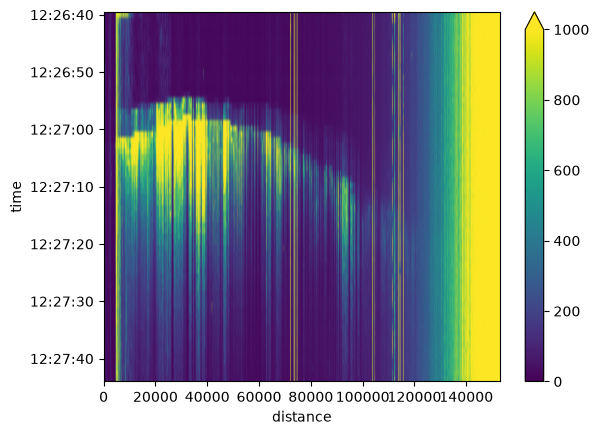

In [22]:
pipeline = xd.filter(
    ..., (1.0, None), ftype="iir", order=4, dim="time"
) >> BlockRMS(1.0, dim="time")

rms = pipeline.process(da, chunks={"time": 1000})
rms.plot(yincrease=False, vmin=0, vmax=1e3, interpolation="antialiased")

```{note}
For realtime, `save_state` and `load_state` write the carried state to disk
and read it back, so that a restarted process picks up where the previous one
stopped instead of warming up again. Splitting the state that can be
recomputed into `initialize_from_state` keeps what has to be saved down to
the minimum.
```

## Picking phases on a large dataset

Machine-learning pickers are the same kind of problem — a model that wants
fixed-length windows, applied to something far longer. `xd.pick` wraps the
whole chain: it reads the weight set to find the rate the model expects,
resamples to it, runs the model with the window overlap and blinding it
declares, and triggers on the resulting probabilities.

In [23]:
from seisbench.models import PhaseNet

model = PhaseNet.from_pretrained("diting")
model.labels  # noise, P, S

'NPS'

In [24]:
da = xd.open("outputs/singlecable.nc")
da

<xdas.DataArray (time: 37500, distance: 10000)>
VirtualSource: 715.3MB (int16)
Coordinates:
  * distance (distance): 0.000 to 153179.709
  * time (time): 2023-11-03T12:20:01.000 to 2023-11-03T12:30:00.984
    latitude (distance): [nan ... nan]
    longitude (distance): [nan ... nan]

The threshold is given per phase, which is also how the noise class gets
dropped — it is simply never asked for. Select phases by *name*: the label
order differs from one weight set to the next, so a position would be a bug
waiting to happen.

For a real archive, the same thing in atom form, streaming its table straight
to a CSV file:

In [25]:
%rm -f outputs/picks.csv

In [26]:
pipeline = (
    xd.resample(..., interval=500, snap=True, dim="distance")
    >> xd.pick(..., model, thresh={"P": 0.3, "S": 0.3}, device="cpu", dim="time")
)

In [27]:
picks = pipeline.process(da, out="outputs/picks.csv", chunks={"time": 3750})

  0%|          | 0.00/715M [00:00<?, ?B/s]

 10%|█         | 71.5M/715M [00:00<00:02, 289MB/s]

 10%|█         | 71.5M/715M [00:00<00:02, 289MB/s, read=12.0%, proc=88.0%, write=0.0%]

 20%|██        | 143M/715M [00:03<00:14, 42.3MB/s, read=12.0%, proc=88.0%, write=0.0%]

 20%|██        | 143M/715M [00:03<00:14, 42.3MB/s, read=0.0%, proc=99.9%, write=0.1%] 

...

 90%|█████████ | 644M/715M [00:22<00:02, 26.9MB/s, read=0.1%, proc=99.9%, write=0.0%]

100%|██████████| 715M/715M [00:25<00:00, 26.8MB/s, read=0.1%, proc=99.9%, write=0.0%]

100%|██████████| 715M/715M [00:25<00:00, 26.8MB/s, read=0.0%, proc=100.0%, write=0.0%]

100%|██████████| 715M/715M [00:27<00:00, 26.8MB/s, read=0.2%, proc=99.8%, write=0.0%] 

100%|██████████| 715M/715M [00:27<00:00, 27.7MB/s, read=0.2%, proc=99.8%, write=0.0%]

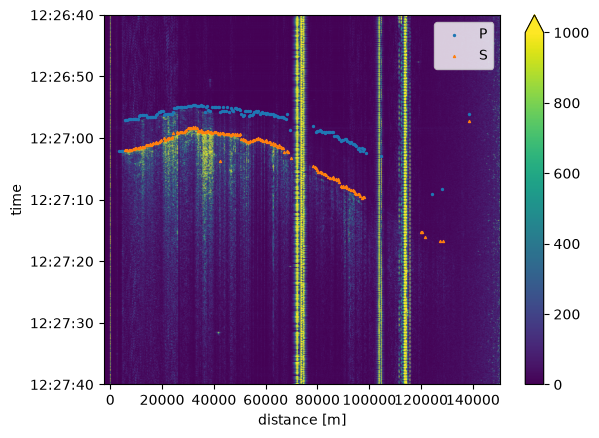

In [28]:
import matplotlib.pyplot as plt

monolithic.plot(vmin=0, vmax=1e3, interpolation="antialiased")

for phase, marker in [("P", "o"), ("S", "^")]:
    sub = picks[picks["phase"] == phase]
    plt.scatter(sub["distance"], sub["time"], s=2, marker=marker, label=phase)

plt.legend()
plt.ylim(np.datetime64("2023-11-03T12:27:40"), np.datetime64("2023-11-03T12:26:40"))
plt.xlabel("distance [m]")
plt.ylabel("time")
plt.show()

Two moveouts, converging near 40 km along the cable: the P and S arrivals of
a regional earthquake. The next notebook turns them into a located event.